In [2]:
import pandas as pd


In [3]:
!unzip games.csv\ \(1\).zip

Archive:  games.csv (1).zip
  inflating: games.csv               


In [4]:
datos = pd.read_csv("games.csv")

In [5]:
datos.head()

,name,release_date,price,positive,negative,app_id,min_owners,max_owners,hltb_single
0,Train Bandit,"Oct 12, 2017",0.99,53,5,655370,0,20000,NaN
1,Henosis™,"Jul 23, 2020",5.99,3,0,1355720,0,20000,NaN
2,Two Weeks in Painland,"Feb 3, 2020",0.00,50,8,1139950,0,20000,NaN
3,Wartune Reborn,"Feb 26, 2021",0.00,87,49,1469160,50000,100000,NaN
4,TD Worlds,"Jan 9, 2022",10.99,21,7,1659180,0,20000,NaN


In [6]:
datos["release_date"].value_counts()

,count
release_date,
"Jan 17, 2020",76
"Sep 14, 2018",68
"Sep 30, 2021",67
"Oct 15, 2020",66
"Oct 14, 2021",62
...,...
Apr 2022,1
"Dec 24, 2016",1
"Nov 17, 2014",1


In [7]:
datos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60952 entries, 0 to 60951
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   name          60952 non-null  object 
 1   release_date  60952 non-null  object 
 2   price         60952 non-null  float64
 3   positive      60952 non-null  int64  
 4   negative      60952 non-null  int64  
 5   app_id        60952 non-null  int64  
 6   min_owners    60952 non-null  int64  
 7   max_owners    60952 non-null  int64  
 8   hltb_single   12972 non-null  float64
dtypes: float64(2), int64(5), object(2)
memory usage: 4.2+ MB


In [8]:
datos.describe()

,price,positive,negative,app_id,min_owners,max_owners,hltb_single
count,60952.000000,6.095200e+04,60952.000000,6.095200e+04,6.095200e+04,6.095200e+04,12972.000000
mean,7.819159,1.045975e+03,193.455326,1.165637e+06,5.489319e+04,1.353160e+05,7.633595
std,9.756732,1.498527e+04,4408.960253,5.986746e+05,6.753193e+05,1.451847e+06,11.943980
min,0.000000,0.000000e+00,0.000000,5.700000e+02,0.000000e+00,2.000000e+04,1.000000
25%,1.990000,4.000000e+00,1.000000,6.760850e+05,0.000000e+00,2.000000e+04,1.000000
50%,4.990000,1.600000e+01,4.000000,1.095830e+06,0.000000e+00,2.000000e+04,3.000000
75%,9.990000,8.000000e+01,24.000000,1.579002e+06,2.000000e+04,5.000000e+04,8.000000
max,299.900000,1.477153e+06,895978.000000,2.690780e+06,1.000000e+08,2.000000e+08,100.000000


array([[<Axes: title={'center': 'price'}>,
        <Axes: title={'center': 'positive'}>,
        <Axes: title={'center': 'negative'}>],
       [<Axes: title={'center': 'app_id'}>,
        <Axes: title={'center': 'min_owners'}>,
        <Axes: title={'center': 'max_owners'}>],
       [<Axes: title={'center': 'hltb_single'}>, <Axes: >, <Axes: >]],
      dtype=object)

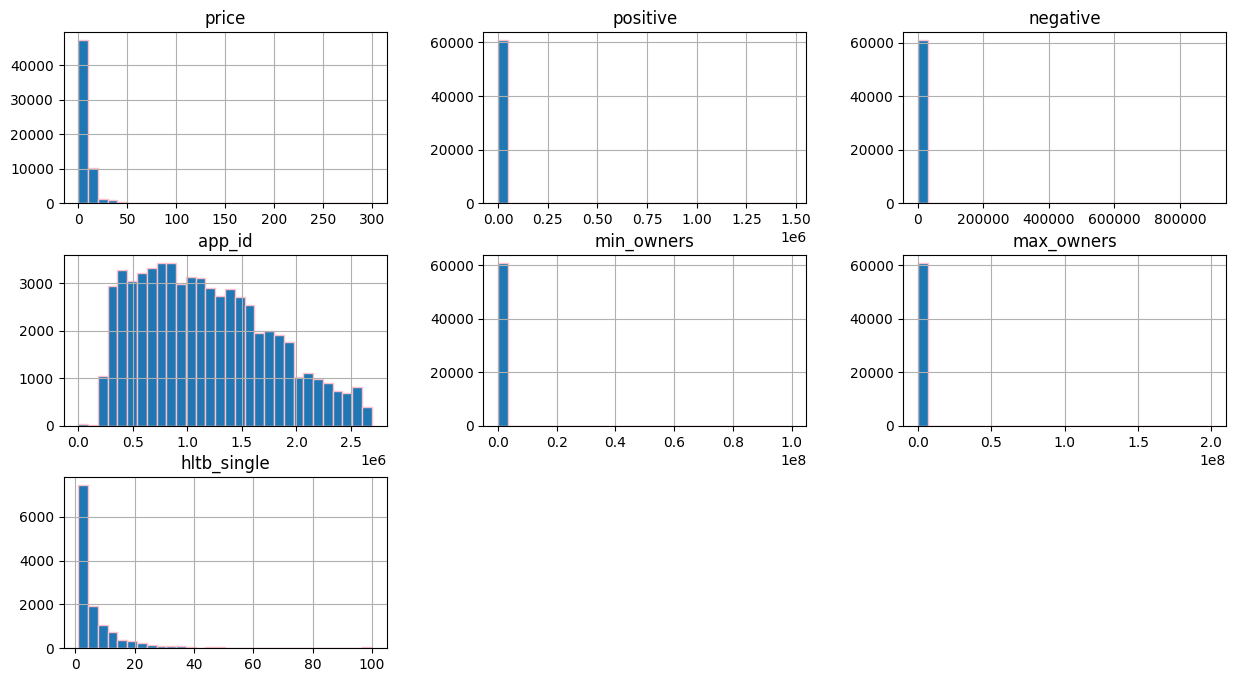

In [9]:
datos.hist(figsize=(15, 8), bins=30, edgecolor="pink")

<Axes: xlabel='price', ylabel='positive'>

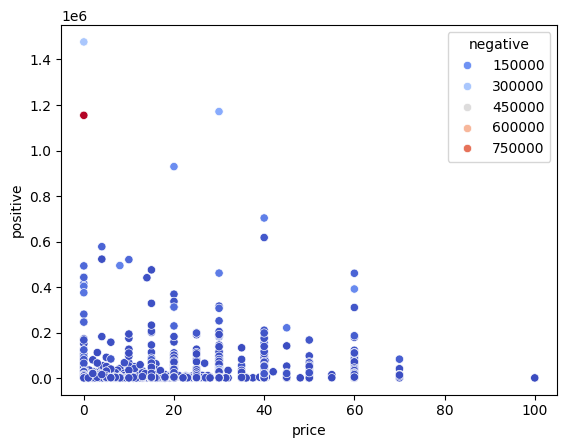

In [11]:
import seaborn as sb
sb.scatterplot(x="price", y="positive", data=datos[(datos.positive > 1000)], hue = "negative", palette="coolwarm")

<Axes: xlabel='price', ylabel='positive'>

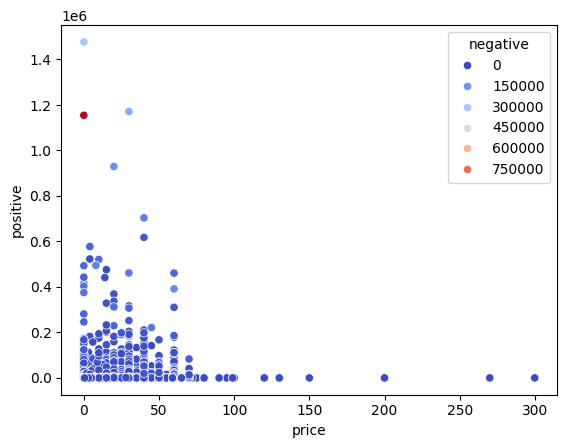

In [12]:
sb.scatterplot(x="price", y="positive", data=datos, hue = "negative", palette="coolwarm")

In [13]:
datos_na = datos.dropna()

In [14]:
datos_na.info()

<class 'pandas.core.frame.DataFrame'>
Index: 12972 entries, 5 to 58095
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   name          12972 non-null  object 
 1   release_date  12972 non-null  object 
 2   price         12972 non-null  float64
 3   positive      12972 non-null  int64  
 4   negative      12972 non-null  int64  
 5   app_id        12972 non-null  int64  
 6   min_owners    12972 non-null  int64  
 7   max_owners    12972 non-null  int64  
 8   hltb_single   12972 non-null  float64
dtypes: float64(2), int64(5), object(2)
memory usage: 1013.4+ KB


In [15]:
datos_na["release_date"]

,release_date
5,"Apr 2, 2020"
6,"Nov 11, 2014"
7,"Oct 2, 2019"
8,"Jul 1, 2016"
13,"Feb 20, 2015"
...,...
58076,"May 30, 2014"
58081,"Jun 6, 2014"
58083,"Jan 9, 2018"
58087,"Sep 10, 2015"


In [16]:
datos_na["release_date"].value_counts()

,count
release_date,
"Oct 15, 2020",29
"May 5, 2014",28
"Apr 5, 2016",25
"Jun 6, 2014",24
"Feb 8, 2018",24
...,...
"Mar 15, 2015",1
"Feb 19, 2013",1
"Jan 19, 2021",1


In [17]:
dummies = pd.get_dummies(datos_na["release_date"], dtype=int)

In [18]:
datos_na = datos_na.join(dummies)

In [19]:
datos_na.head()

,name,release_date,price,positive,negative,app_id,min_owners,max_owners,hltb_single,"Apr 1, 2014",...,"Sep 8, 2016","Sep 8, 2017","Sep 8, 2018","Sep 8, 2020","Sep 8, 2021","Sep 9, 2014","Sep 9, 2015","Sep 9, 2016","Sep 9, 2019","Sep 9, 2021"
5,MazM: Jekyll and Hyde,"Apr 2, 2020",14.99,76,6,1178150,0,20000,7.0,0,...,0,0,0,0,0,0,0,0,0,0
6,Deadlings: Rotten Edition,"Nov 11, 2014",3.99,225,45,320150,50000,100000,4.0,0,...,0,0,0,0,0,0,0,0,0,0
7,WARSAW,"Oct 2, 2019",23.99,589,212,1026420,20000,50000,5.0,0,...,0,0,0,0,0,0,0,0,0,0
8,Cthulhu Realms,"Jul 1, 2016",0.00,147,58,485000,50000,100000,3.0,0,...,0,0,0,0,0,0,0,0,0,0
13,Hero of the Kingdom II,"Feb 20, 2015",7.99,2046,120,346560,100000,200000,5.0,0,...,0,0,0,0,0,0,0,0,0,0


In [20]:
datos_na = datos_na.drop(['release_date'], axis=1,)

In [21]:
datos_na.head()

,name,price,positive,negative,app_id,min_owners,max_owners,hltb_single,"Apr 1, 2014","Apr 1, 2015",...,"Sep 8, 2016","Sep 8, 2017","Sep 8, 2018","Sep 8, 2020","Sep 8, 2021","Sep 9, 2014","Sep 9, 2015","Sep 9, 2016","Sep 9, 2019","Sep 9, 2021"
5,MazM: Jekyll and Hyde,14.99,76,6,1178150,0,20000,7.0,0,0,...,0,0,0,0,0,0,0,0,0,0
6,Deadlings: Rotten Edition,3.99,225,45,320150,50000,100000,4.0,0,0,...,0,0,0,0,0,0,0,0,0,0
7,WARSAW,23.99,589,212,1026420,20000,50000,5.0,0,0,...,0,0,0,0,0,0,0,0,0,0
8,Cthulhu Realms,0.00,147,58,485000,50000,100000,3.0,0,0,...,0,0,0,0,0,0,0,0,0,0
13,Hero of the Kingdom II,7.99,2046,120,346560,100000,200000,5.0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [22]:
datos.select_dtypes(include=['number']).corr()

,price,positive,negative,app_id,min_owners,max_owners,hltb_single
price,1.000000,0.081661,0.046055,0.012393,0.049234,0.049836,0.344614
positive,0.081661,1.000000,0.714046,-0.064515,0.815625,0.826195,0.154589
negative,0.046055,0.714046,1.000000,-0.038415,0.675104,0.660100,0.127927
app_id,0.012393,-0.064515,-0.038415,1.000000,-0.072512,-0.072109,-0.056096
min_owners,0.049234,0.815625,0.675104,-0.072512,1.000000,0.994499,0.164353
max_owners,0.049836,0.826195,0.660100,-0.072109,0.994499,1.000000,0.157737
hltb_single,0.344614,0.154589,0.127927,-0.056096,0.164353,0.157737,1.000000


In [27]:
cols = ['price','positive','negative','app_id','min_owners','max_owners','hltb_single']

datos_clean = datos_na[cols]

<Axes: >

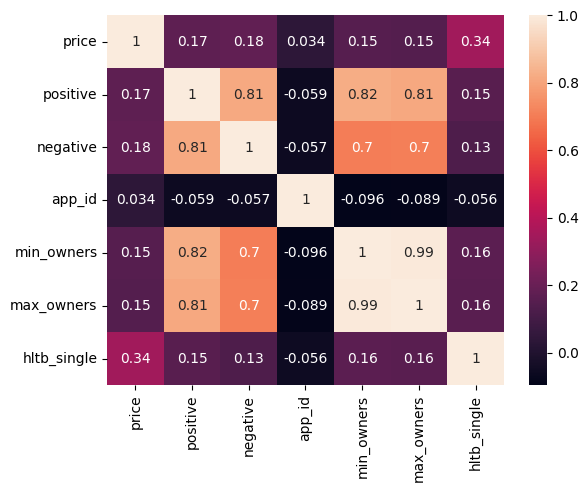

In [32]:
sb.heatmap(datos_na[['price','positive','negative','app_id','min_owners','max_owners','hltb_single']].corr(), annot=True)

In [35]:
datos.select_dtypes(include=['number']).corr()['positive'].sort_values(ascending=False)

,positive
positive,1.000000
max_owners,0.826195
min_owners,0.815625
negative,0.714046
hltb_single,0.154589
price,0.081661
app_id,-0.064515
